# Hitting Times

A **hitting time** answers one question: *how long until this random process
first reaches some level?*

- How long until a stock first touches \$120?
- How long until a gambler is up \$50?
- How long until an insurer's reserves first hit \$0? (*ruin*)

`hitting_time(process, level=...)` gives you the answer as a random variable,
which you can then simulate, plot, and summarize like anything else.

In [1]:
from symbulate import *
import matplotlib.pyplot as plt

## Simulate some paths and pick a level

Below are five paths of a Brownian motion -- a random wander that starts at 0.
The dashed line is the level 1. For each path, the hitting time is the first
moment it touches that line. Some paths get there quickly, some late, and some
never get there at all.

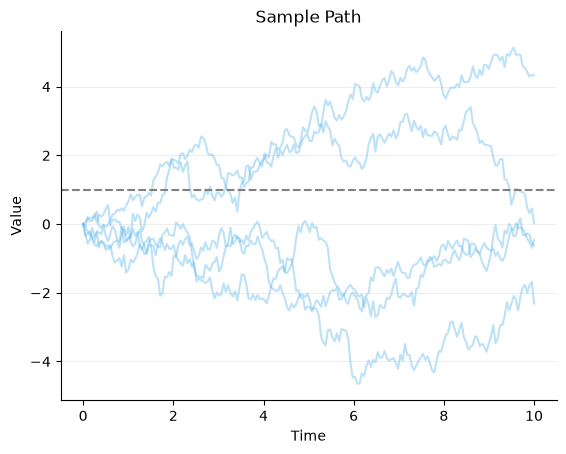

In [2]:
B = BrownianMotion()

B.sim(5).plot(tmin=0, tmax=10)
plt.axhline(1, color="gray", linestyle="--");

## Ask for the hitting time

`max_time` is how long to keep looking before giving up. You need it because
the level might never be reached, and in that case the honest answer is `inf`
(infinity).

The result is a random variable, so simulate it. Each value is how long that
one path took to reach 1.

In [3]:
T = hitting_time(B, level=1, max_time=20)

times = T.sim(1000)
times

0,inf
1,1.3591793060302733
2,0.8609371185302734
3,4.849976730346681
4,0.19999961853027345
5,9.959221267700189
6,0.7998043060302734
7,inf
8,15.036729812622053
...,...
999,1.9301876068115233


Look closely and some of those values are `inf`: those paths never got to 1
within the 20 units of time we allowed. That is not a failure, it is a real
feature of hitting times -- some paths simply wander the wrong way the whole
time.

So the first thing to report is how many paths arrived at all.

In [4]:
print(f"reached level 1 within 20:  {times.count_leq(20)} of 1000 paths")

reached level 1 within 20:  817 of 1000 paths


## The shape of the distribution

To plot only the paths that arrived, drop the infinities first with
`filter_leq`. Most paths reach the level early, but the tail is very long -- a
few take almost the whole window.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


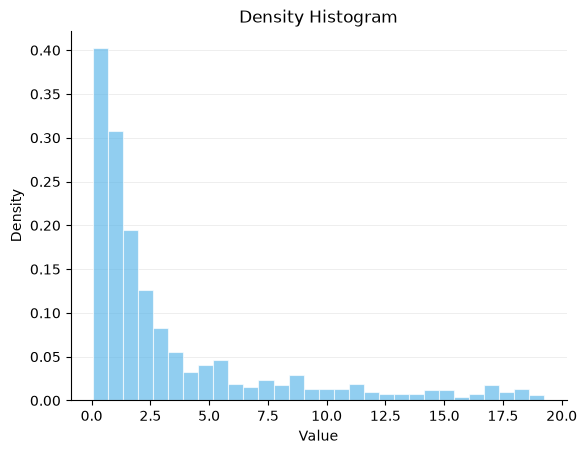

In [5]:
times.filter_leq(20).plot()

That tail is so long that the **average is infinite** -- not merely large,
actually infinite. Symbulate reports that honestly:

In [6]:
times.mean()

inf

So quote the **median** of the paths that arrived instead. Half of them got
there faster than this, half slower.

In [7]:
times.filter_leq(20).median()

1.5308589935302734

## Checking it against a known answer

Brownian motion is one of the few processes where the answer is known on paper.
The chance of reaching level `a` by time `t` is exactly `2 * Phi(-a / sqrt(t))`,
where `Phi` is the normal CDF -- the `.cdf` of a standard `Normal`. Simulation
and formula agree:

In [8]:
Z = Normal(mean=0, sd=1)

for max_time in [1, 4, 16]:
    reached = hitting_time(B, level=1, max_time=max_time).sim(2000).count_leq(max_time)
    exact = 2 * Z.cdf(-1 / max_time**0.5)
    print(f"by time {max_time:>2}:  simulated {reached / 2000:.3f}   exact {exact:.3f}")

by time  1:  simulated 0.304   exact 0.317


by time  4:  simulated 0.618   exact 0.617


by time 16:  simulated 0.794   exact 0.803


## Compare with a process that drifts upward

The answer belongs to the process, not just to the level. `BrownianMotion` with
no drift has no reason to prefer up over down, which is why so many paths never
arrive. Give it a steady upward push and almost all of them do.

In [9]:
drifting = hitting_time(BrownianMotion(drift=1), level=1, max_time=20).sim(1000)

print(f"no drift, reached 1 within 20:  {times.count_leq(20)} of 1000")
print(f"drift 1,  reached 1 within 20:  {drifting.count_leq(20)} of 1000")

no drift, reached 1 within 20:  817 of 1000
drift 1,  reached 1 within 20:  1000 of 1000


## Falling to a level works too

You never say which direction. If the path starts *below* the level,
`hitting_time` looks for the first time it rises to it; if it starts *above*,
the first time it falls to it. Brownian motion starts at 0, so level -1 means
falling. By symmetry, reaching -1 should be just as likely as reaching +1.

In [10]:
up = hitting_time(B, level=1, max_time=4).sim(2000)
down = hitting_time(B, level=-1, max_time=4).sim(2000)

print(f"reached +1 within 4:  {up.count_leq(4)} of 2000")
print(f"reached -1 within 4:  {down.count_leq(4)} of 2000")

reached +1 within 4:  1221 of 2000
reached -1 within 4:  1213 of 2000


## A more realistic question

Put it together with a stock price. A share is worth \$100 today and you want
to sell at \$120. How long might that take?

In [11]:
stock = GeometricBrownianMotion(initial_value=100, growth_rate=0.05, scale=0.3)
wait = hitting_time(stock, level=120, max_time=10).sim(1000)

print(f"hit $120 within 10 years:  {wait.count_leq(10)} of 1000")
print(f"median wait, if it did:    {wait.filter_leq(10).median():.2f} years")

hit $120 within 10 years:  852 of 1000
median wait, if it did:    0.70 years


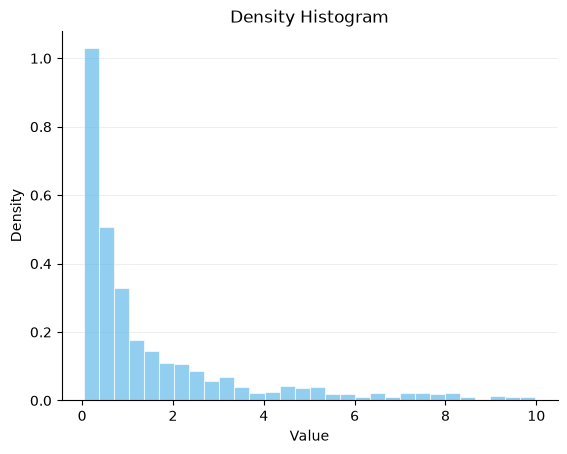

In [12]:
wait.filter_leq(10).plot()

## Why this needs more than a simple scan

Here is the catch, and it is the whole reason this needs a real algorithm
rather than a loop.

A sample path is only ever worked out at the times you ask about. In between
two of those times it is **not** a straight line -- it wiggles. So the path can
pop above the level and come back down without either of the times you looked
at noticing.

Take one path and look at it more and more finely, each time reporting the
highest value seen:

In [13]:
path = BrownianMotion().draw()

for step in [2, 0.5, 0.01]:
    checked = [step * i for i in range(int(10 / step) + 1)]
    print(f"checking every {step:>4}:  highest value seen is {max(path(t) for t in checked):.2f}")

checking every    2:  highest value seen is 0.00
checking every  0.5:  highest value seen is 0.00


checking every 0.01:  highest value seen is 0.07


The number never goes down as you look more finely, and it usually goes up.
Every increase is somewhere the path went that the coarser check walked
straight past -- so any level in between was reached without being noticed.
Looking more finely always finds more, and you can never be sure you have
looked finely enough. A plain scan would report hitting times that are **too
late**, or miss crossings completely.

`hitting_time` avoids the problem instead of out-running it. For a Brownian
motion there is a formula for the *probability* that the path crossed a level
between two values you do know. So rather than looking harder, it flips a coin
weighted by that probability, and nothing can hide. When the coin says a
crossing happened, it cuts the stretch in half over and over to work out when.
The formula and the details are in `symbulate/hitting_times.py`.

## Three things to know

**1. `step` controls precision, not just speed** -- for a *Gaussian* process.
`step` is how far ahead the search looks at a time. Whether the level was
reached, and which `step`-sized stretch it happened in, is exact for Brownian
motion. But pinning down *where inside* that stretch is approximate and leans
slightly late, so the reported time is good to about one `step`. The default
(the search window split into 100) is fine for plotting a distribution; use a
smaller `step` if you need sharp individual times. For the jump and
discrete-time processes below, `step` does nothing at all -- they are exact.

**2. `start_time` looks for a later crossing.** A hitting time is the *first*
time the level is reached. Pass `start_time` to begin the search later on --
just past an earlier crossing, say -- and you get the next one instead.

**3. Three kinds of process are handled, and the accuracy differs.** Gaussian
processes (above) need the crossing formula. Processes that move in jumps, and
discrete-time processes, do not -- and are exact. The rest of this notebook is
about those two.

## Processes that move in jumps

A Poisson process, a queue length, a continuous-time Markov chain, a compound
Poisson total: all of these **hold one value at a time** and change only at
their jumps. That makes hitting times easy *and* exact -- a path that is flat
between jumps cannot sneak past a level and back, so walking the jumps sees
everything. Nothing wiggles, nothing is missed, and no `step` is needed.

Start with a Poisson process. Its count reaches 4 at the moment of the 4th
arrival, so its hitting time *is* the 4th arrival time -- which we can check
exactly, on a single path.

In [14]:
N = PoissonProcess(rate=2)
path = N.draw()

print(f"4th arrival time:        {float(path.get_arrival_times()[3]):.6f}")
print(f"time the count hits 4:   {hitting_time(path, level=4, max_time=100):.6f}")

4th arrival time:        0.826836
time the count hits 4:   0.826836


Identical, not merely close. And because the 4th arrival of a rate-2 Poisson
process has a `Gamma(4, 2)` distribution, the mean hitting time is exactly
`4 / 2 = 2` -- another answer known on paper to check against.

In [15]:
arrivals = hitting_time(N, level=4, max_time=1000).sim(10000)
print(f"simulated mean:  {arrivals.mean():.3f}")
print(f"exact (k / rate): {4 / 2:.3f}")

simulated mean:  1.998
exact (k / rate): 2.000


### How long until the queue has five people in it?

The same call works on a queue, where the path is the number of customers in
the system. This is the question the utility exists for: it is not a formula
anyone wants to derive for a general-service queue.

In [16]:
queue = GG1(Exponential(rate=1), Exponential(rate=1.2))
busy = hitting_time(queue, level=5, max_time=200).sim(1000)

print(f"reached 5 in line within 200:  {busy.count_leq(200)} of 1000")
print(f"median wait until it did:      {busy.filter_leq(200).median():.1f}")

reached 5 in line within 200:  1000 of 1000
median wait until it did:      13.3


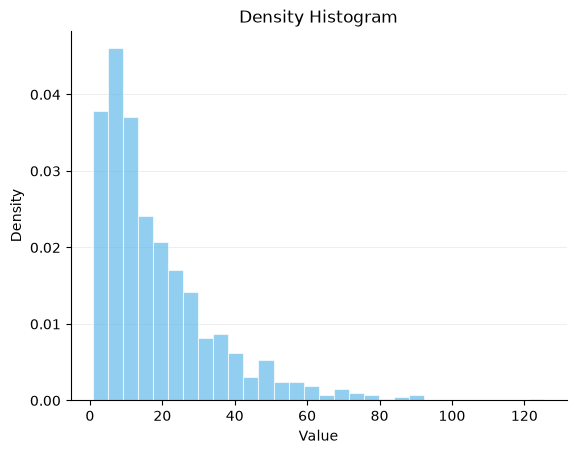

In [17]:
busy.filter_leq(200).plot()

### Ruin

An insurer's surplus goes up with premiums and down with claims. Model the net
change as a compound Poisson process with negative jumps, and *ruin* is the
first time the surplus falls to a level -- which is a hitting time, not a
separate thing to build.

In [18]:
surplus = CompoundPoissonProcess(rate=1, jump_dist=Normal(mean=-1, sd=3))
ruin = hitting_time(surplus, level=-20, max_time=100).sim(1000)

print(f"ruined (fell to -20) within 100:  {ruin.count_leq(100)} of 1000")
print(f"median time to ruin, if ruined:   {ruin.filter_leq(100).median():.1f}")

ruined (fell to -20) within 100:  998 of 1000
median time to ruin, if ruined:   17.7


## Discrete-time processes

A random walk, a Markov chain, and a moving-average series have a value at each
step and nothing in between, so again there is nothing to miss. The answer here
is a **step number**, because for these processes a step *is* the unit of time
-- and so is `max_time`.

The classic check: a `+-1` walk that steps up with probability `p > 1/2` reaches
level 1 after `1 / (2p - 1)` steps on average.

In [19]:
walk = RandomWalk(p=0.7)
steps = hitting_time(walk, level=1, max_time=2000).sim(5000)

print(f"simulated mean steps:  {steps.mean():.3f}")
print(f"exact 1 / (2p - 1):    {1 / (2 * 0.7 - 1):.3f}")

simulated mean steps:  2.428
exact 1 / (2p - 1):    2.500


And the other classic: a walk drifting *downward* reaches level 1 only
sometimes -- with probability `p / (1 - p)`, and never otherwise. The paths that
never make it report `inf`, which is the honest answer rather than a very large
number.

In [20]:
sinking = hitting_time(RandomWalk(p=0.3), level=1, max_time=1000).sim(2000)

print(f"ever reached 1:   {sinking.count_leq(1000) / 2000:.3f}")
print(f"exact p / (1 - p): {0.3 / 0.7:.3f}")

ever reached 1:   0.435
exact p / (1 - p): 0.429


### One difference worth knowing: reaching means reaching *or passing*

A walk that goes from 4 to 6 is never at 5. So for a jump or discrete-time
process, "reaching a level" has to mean getting to it **or past it** -- and
asking about 4.5 gives the same answer as asking about 5.

(For a Gaussian process this cannot come up: a continuous path has no way to get
to the other side of a level without touching it.)

In [21]:
climbing = RandomWalk(p=1).draw()  # steps up by 1 every time: 0, 1, 2, 3, ...

for level in [4, 4.5, 5]:
    print(f"level {level}: reached at step {hitting_time(climbing, level=level, max_time=50)}")

level 4: reached at step 4.0
level 4.5: reached at step 5.0
level 5: reached at step 5.0


### When does the weather first turn?

A Markov chain works the same way, with one catch: a level needs an *order*, so
label the states with numbers rather than names. Starting in state 0 of the
chain below, the first step spent in state 1 is geometric with success
probability 0.25, so it takes 4 steps on average.

In [22]:
chain = MarkovChain([[0.75, 0.25], [0.5, 0.5]], [1.0, 0.0])
first_visit = hitting_time(chain, level=1, max_time=500).sim(5000)

print(f"simulated mean steps:  {first_visit.mean():.3f}")
print(f"exact 1 / 0.25:        {1 / 0.25:.3f}")

simulated mean steps:  4.051
exact 1 / 0.25:        4.000


Label the same chain with names and it says so, rather than guessing at an
order:

In [23]:
named = MarkovChain(
    [[0.75, 0.25], [0.5, 0.5]], [1.0, 0.0], state_labels=["sun", "rain"]
)

try:
    hitting_time(named.draw(), level=1)
except TypeError as error:
    print(error)

At step 0, the process is at 'sun', which is not a number, so there is no way to tell whether it has reached a level. Asking when a process reaches a level only makes sense for one whose values are numbers. If this is a Markov chain, label its states with numbers -- MarkovChain(P, initial, state_labels=[0, 1, 2]) -- rather than with names.


## What is not handled yet

A general diffusion -- `DiffusionProcess` or `CIR` -- needs its own
approximation, which is not built. So does a
`NonHomogeneousPoissonProcess` or `CoxProcess` count: it *does* move in jumps,
but it knows when those jumps happen on the "expected number of events" scale
rather than on the clock, and working back to a time from that is not built
either. Both say so plainly instead of returning a wrong number.

In [24]:
for process in [CIR(), CoxProcess(intensity=Gamma(shape=2, rate=1))]:
    try:
        hitting_time(process.draw(), level=3, max_time=50)
    except NotImplementedError as error:
        print(type(process).__name__, "->", error, "\n")

CIR -> hitting_time does not know how to read a CIRResult yet. It handles Gaussian processes (BrownianMotion, BrownianBridge, OrnsteinUhlenbeck, FractionalBrownianMotion, GeometricBrownianMotion, or a GaussianProcess you built yourself), processes that move in jumps (PoissonProcess, RenewalProcess, CompoundPoissonProcess, ContinuousTimeMarkovChain, the birth-death and M/M queues, and the G/G queues), and discrete-time processes (RandomWalk, MarkovChain, MA). A DiffusionProcess, CIR, or MertonJumpDiffusion needs its own approximation, which is not built yet -- a Merton jump diffusion wanders continuously between its jumps, so walking the jumps would miss everything in between. A process whose value is several numbers at once, such as an epidemic model, has no single level to reach, and neither it nor one of its compartments on its own is handled yet. 

CoxProcess -> hitting_time cannot read a NonHomogeneousPoissonProcess or CoxProcess path yet. Its count does move in jumps, but unlike a

## Every crossing, not just the first

A hitting time is the *first* time a process reaches a level. But a process that
moves both ways gets there again, and again:

- How many times did the queue fill up this month, and when?
- Every time the gambler got back to even.
- Each time the reservoir refilled to capacity.

`upcrossings(process, level=...)` gives you those times in order. On a single
path it is a sequence you can index; on a whole process each entry is a random
variable, so `upcrossings(X, level=3)[2]` is "the time of the third crossing"
and simulates like anything else. Positions past the last crossing are `inf`,
the same convention `hitting_time` uses for a level that was never reached.

It is computed only as far as you look, so asking for `[2]` finds three
crossings and stops there.

In [25]:
weather = MarkovChain([[0.75, 0.25], [0.5, 0.5]], [1.0, 0.0]).draw()
days = "".join("R" if weather[n] == 1 else "." for n in range(30))

print("30 days of it: ", days, "  (R = rain)")
print("rain starts on:", [upcrossings(weather, level=1, max_time=29)[n] for n in range(4)])

30 days of it:  ..R.....RR.....RRR....R..RRR.R   (R = rain)
rain starts on: [2.0, 8.0, 15.0, 22.0]


Each of those is the first `R` after a run of dots, so you can check every one
of them by counting along the row above.

### A crossing comes from *below*

Between one crossing and the next the path has to drop back **under** the level.
That is what holds the crossings apart and makes them a sequence -- and it means
sitting *on* the level is not crossing it. A path that goes 0, 3, 3, 3 has
crossed level 1 once, not four times.

It also means that a path already at or above the level when you start looking
is not crossing it yet: it has to dip under first. So `upcrossings(...)[0]` can
come later than `hitting_time(...)`, and when it does, the two are answering
genuinely different questions -- `hitting_time` reads its direction off the
path, so a path starting *above* the level has it waiting for the fall down to
it, while `upcrossings` is always waiting for a rise.

In [26]:
def path_with(values):
    """A discrete-time path whose steps are exactly `values`, then flat."""
    return RandomProcess(
        Bernoulli(p=1) ** inf,
        DiscreteTimeSequence(fs=1),
        lambda outcome, n: values[min(n, len(values) - 1)],
    ).draw()


held = path_with([0, 3, 3, 3, 0, 3])
print("steps:          ", [int(held[n]) for n in range(6)])
print("crossings of 1: ", [upcrossings(held, level=1, max_time=5)[n] for n in range(3)])

above = path_with([5, 5, 0, 5])
print()
print("steps:          ", [int(above[n]) for n in range(4)])
print("crossings of 1: ", [upcrossings(above, level=1, max_time=3)[n] for n in range(2)])
print("hitting time:   ", hitting_time(above, level=1, max_time=3), "(the fall to 1)")

steps:           [0, 3, 3, 3, 0, 3]
crossings of 1:  [1.0, 5.0, inf]

steps:           [5, 5, 0, 5]
crossings of 1:  [3.0, inf]
hitting time:    2.0 (the fall to 1)


### Checking it against a known answer

Take a two-state continuous-time Markov chain flipping between calm (0) and busy
(1), with rates `q01 = 2` and `q10 = 1`. One full cycle is a stay in state 1
followed by a stay in state 0, so the gap between one upcrossing of level 1 and
the next is a sum of two exponentials, with mean `1 / q10 + 1 / q01` exactly.

In [27]:
switching = ContinuousTimeMarkovChain([[-2, 2], [1, -1]], [1.0, 0.0])
busy_times = upcrossings(switching, level=1, max_time=1000)

first = busy_times[0].sim(5000)
gaps = (busy_times[1] - busy_times[0]).sim(5000)

print(f"mean time until first busy:  {first.mean():.3f}    exact 1 / q01       = {1 / 2:.3f}")
print(f"mean gap between busy runs:  {gaps.mean():.3f}    exact 1/q10 + 1/q01 = {1 / 1 + 1 / 2:.3f}")

mean time until first busy:  0.505    exact 1 / q01       = 0.500
mean gap between busy runs:  1.472    exact 1/q10 + 1/q01 = 1.500


Being a sum of two exponentials rather than one, the gap rises to a peak before
it decays -- it does not pile up at zero the way a single exponential does.

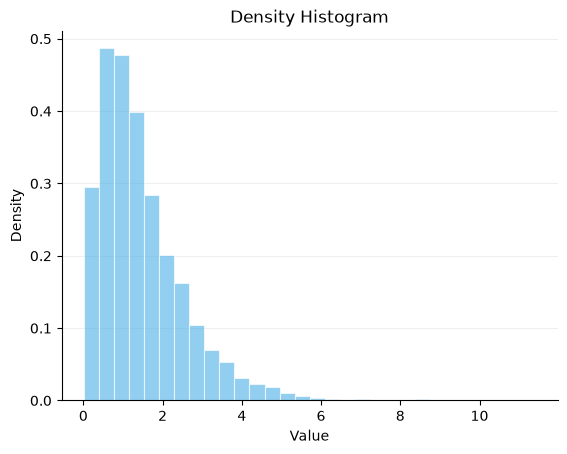

In [28]:
gaps.plot()

### A count crosses a level once and never again

A Poisson process count only ever goes up, so it never comes back below a level
to cross it a second time: the sequence is the hitting time followed by `inf`
forever. Correct, if not very interesting -- upcrossings are for processes that
move both ways, like the queue length underneath it here.

In [29]:
count = PoissonProcess(rate=2).draw()
print("count crossings of 4:", [upcrossings(count, level=4, max_time=100)[n] for n in range(3)])
print("count hitting time:  ", hitting_time(count, level=4, max_time=100))

queue_path = GG1(Exponential(rate=1), Exponential(rate=1.2)).draw()
print()
print(
    "queue reaches 5 people at:",
    [round(upcrossings(queue_path, level=5, max_time=200)[n], 2) for n in range(4)],
)

count crossings of 4: [2.0530213197916454, inf, inf]
count hitting time:   2.0530213197916454

queue reaches 5 people at: [3.34, 39.57, 69.05, 72.13]


### Why a single level is not enough for Brownian motion

Not an oversight. A Brownian motion crosses a level **infinitely often**
in every stretch of time after it first touches it, however short that
stretch is -- its crossings are packed together rather than coming one
after another. So there is no second or third crossing of that one level
to hand back. Any count you produced would be a count of how finely you
happened to look, and it would keep climbing the more finely you looked.

`upcrossings` says so rather than returning a number that depends on a
setting you chose -- and it tells you what to ask instead.

In [30]:
try:
    upcrossings(BrownianMotion(), level=1).sim(1)
except NotImplementedError as error:
    print(error)

upcrossings needs a reset level to list the crossing times of a GaussianProcessResult path, because a level on its own has no first, second, third crossing to list. A path that moves continuously recrosses a level infinitely often in every stretch of time after it first touches it, however short that stretch is, so its crossings of that one level are packed together rather than coming one after another, and any count of them would only report how finely the path happened to be looked at. Say how far back the path has to come before a crossing counts again and the question has an answer: upcrossings(path, level=1, reset=0) is the times it reaches 1 having been down to 0 in between. Alternatively hitting_time works here as it is, and asking it again from a later start_time gives a later crossing.


You can watch the count run away. Take one Brownian path, look at it on finer
and finer grids, and each time count how often it went from below 0 to at-or-above
it -- the same thing `upcrossings` would report if it trusted a grid. (This is
the "why this needs more than a simple scan" cell near the top of the notebook
again, now counted rather than maximized.)

In [31]:
path = BrownianMotion().draw()

for step in [0.1, 0.01, 0.001]:
    values = [path(step * i) for i in range(int(1 / step) + 1)]
    seen = sum(1 for before, after in zip(values, values[1:]) if before < 0 <= after)
    print(f"looking every {step:>5}:  {seen} crossings of 0 in the first time unit")

looking every   0.1:  1 crossings of 0 in the first time unit
looking every  0.01:  2 crossings of 0 in the first time unit


looking every 0.001:  6 crossings of 0 in the first time unit


It goes up every time, and it would go on going up forever -- there is no
grid fine enough to settle on an answer. A jump or discrete-time process
has no such problem: its values *are* the whole path, so there is nothing
finer to look at, and the crossings above are the real ones.

For a continuous process the fix is not a finer grid. It is a slightly
different question.

## Two levels: `reset`

The trouble with "when does it reach 1 again?" is that the path never
really leaves 1 once it gets there. So ask a slightly different question:

> When does it reach 1, **having been back down to -1** first?

Now the path has real ground to cover between one crossing and the next,
so only finitely many of them fit into a finite stretch of time. That is
what `reset` is -- the level the path has to get back to before another
crossing counts.

`reset` is not a setting to tune. It is part of the question. *Reaches 110
having dipped to 90* and *reaches 110 having dipped to 109* are different
questions, and both are perfectly good ones.

### What it looks like

An Ornstein-Uhlenbeck process, which wanders around 0 and keeps being
pulled back, so it visits a band over and over. The dashed line is the
level, the dotted line is the reset, and each red line is a crossing.

Look at what is *not* marked. The path touches the dashed line more often
than there are red lines -- a touch only counts once the path has been all
the way down to the dotted line since the last one.

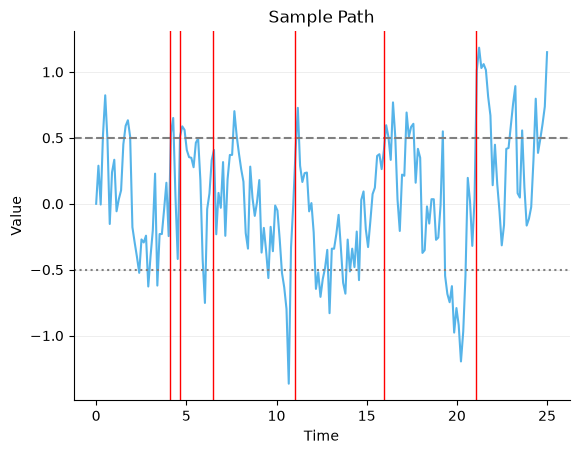

In [32]:
wobbly = OrnsteinUhlenbeck(reversion_rate=1, mean=0, scale=1).draw()

times = upcrossings(wobbly, level=0.5, reset=-0.5, max_time=25, step=0.05)

wobbly.plot(tmin=0, tmax=25)
plt.axhline(0.5, color="gray", linestyle="--")
plt.axhline(-0.5, color="gray", linestyle=":")
for n in range(8):
    if times[n] < inf:
        plt.axvline(times[n], color="red", linewidth=1)

In [33]:
print("reaches 0.5 after dipping to -0.5:", [round(times[n], 2) for n in range(5)])

reaches 0.5 after dipping to -0.5: [4.1, 4.65, 6.48, 11.05, 15.96]


### How much the reset changes the answer

Easiest to see on a random walk, where you can read the values off
directly. A reset just under the level counts nearly every wobble; a reset
far below counts only the real round trips.

This is also the point that `reset` is useful on a jump or step process
too, not only on a continuous one -- here it is what stops a walk that
steps down one and back up from counting as a fresh crossing.

In [34]:
walk = RandomWalk(p=0.5).draw()
print("first 20 steps:", [int(walk[n]) for n in range(20)])
print()

for reset in [None, 2, 0, -3]:
    crossings = upcrossings(walk, level=3, reset=reset, max_time=300)
    found = sum(1 for n in range(40) if crossings[n] < inf)
    print(f"reset {str(reset):>5}:  {found} crossings of 3")

first 20 steps: [0, -1, 0, -1, 0, 1, 0, 1, 2, 1, 2, 3, 2, 1, 2, 3, 4, 5, 4, 3]

reset  None:  2 crossings of 3
reset     2:  2 crossings of 3
reset     0:  1 crossings of 3
reset    -3:  0 crossings of 3


### The count settles down now

This is the payoff. Counting crossings of a single level on a grid gave a
number that climbed every time you looked more finely. With a reset,
looking more finely gives you the same answer -- so the answer is a
property of the process rather than of how hard you squinted.

In [35]:
B = BrownianMotion()

for step in [0.5, 0.1, 0.02]:
    crossings = upcrossings(B, level=0.2, reset=-0.2, max_time=5, step=step)
    counts = [
        sum(1 for k in range(12) if row[k] < inf) for row in crossings.sim(200)
    ]
    print(f"looking every {step:>5}:  {sum(counts) / len(counts):.2f} crossings on average")

looking every   0.5:  2.17 crossings on average


looking every   0.1:  2.10 crossings on average


looking every  0.02:  2.25 crossings on average


### A question worth asking

A share worth \$100 with no expected growth. How long until it recovers to
\$110, having first dropped to \$90? Some paths manage it within months,
and plenty never manage it at all -- those are the `inf`s, dropped before
plotting.

recovered within 5 years:  344 of 500


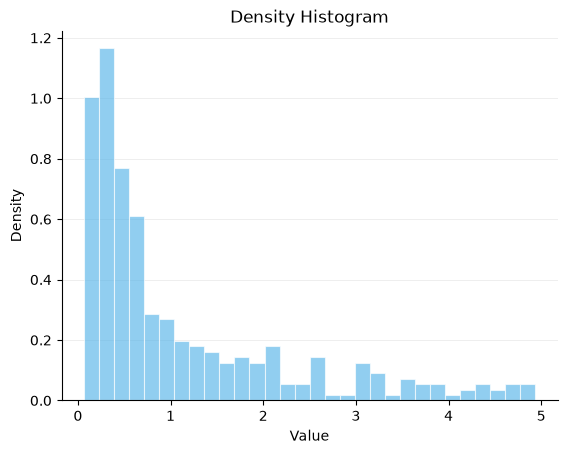

In [36]:
stock = GeometricBrownianMotion(initial=100, growth_rate=0, scale=0.4)

recovery = upcrossings(stock, level=110, reset=90, max_time=5, step=0.02)[0]
recovered = recovery.sim(500)

print(f"recovered within 5 years:  {recovered.count_lt(inf)} of 500")
recovered.filter_lt(inf).plot()

### Crossings downward

Put the reset *above* the level and everything mirrors: you get the times
the path **falls** to the level, each after a trip up to the reset. Which
of the two numbers is the larger is how you say which way round you mean,
so there is no second function to learn.

In [37]:
drops = upcrossings(wobbly, level=-0.5, reset=0.5, max_time=25, step=0.05)

print("falls to -0.5 after rising to 0.5:", [round(drops[n], 2) for n in range(5)])

falls to -0.5 after rising to 0.5: [2.28, 5.93, 7.21, 8.32, 12.12]


### Two things to know

**1. A jump or step process does not need `reset`.** Its crossings are
already separated, and the answer is exact -- which is why every example
earlier in this notebook left `reset` out. `step` and `tol` are accepted
and ignored for those, so one call works across a mix of processes.

**2. For a continuous process the answer is approximate.** Each leg of the
search is a `hitting_time` call, so it inherits that function's accuracy,
and `step` is the knob rather than `tol`. What matters is that the *count*
no longer runs away as `step` shrinks -- that is the table above. On a
process of your own, halve `step` and check the answer holds still.